- Generate UMAPs for SE, 1h, and 6h conditions both with and without IEGs
- Identify CA1 pyramidal neurons and then re-cluster them

In [1]:
import numpy as np
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt

In [2]:
# clusters 1, 3, and 16 from the unfiltered UMAP
adata = ad.read_h5ad('/Volumes/jack/seq/analysis/combined/0_all-sample/DGE_unfiltered/adata_postClustering.h5ad')

# discard all clusters not in 1, 3, and 16
ca1_cells = np.isin(adata.obs['louvain'], ['1', '3', '16'])
adata = adata[ca1_cells, :]
adata.obs['condition'] = adata.obs['sample'].apply(lambda x: x[:2])

adata

KeyError: 'louvain'

/Users/jack/miniconda3/envs/sc/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/Users/jack/miniconda3/envs/sc/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/Users/jack/miniconda3/envs/sc/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_m

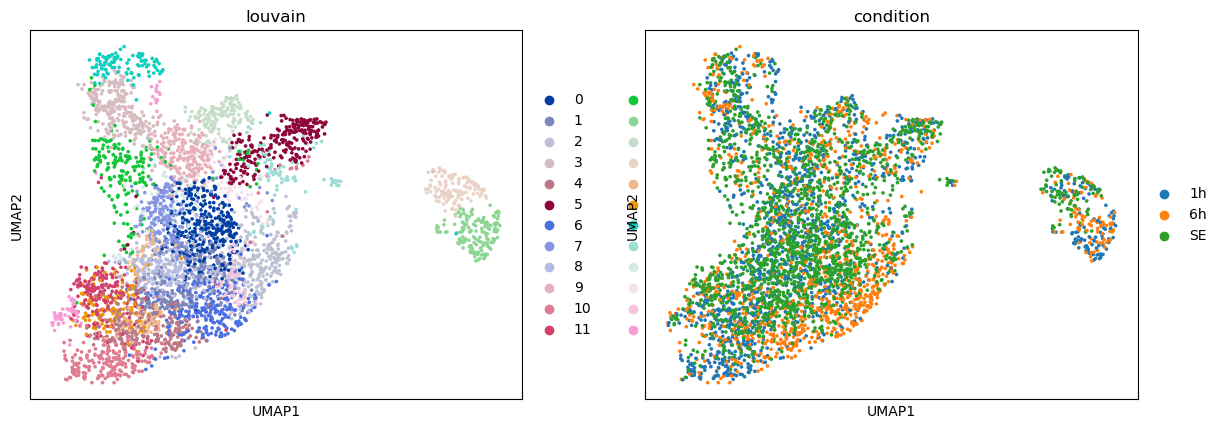

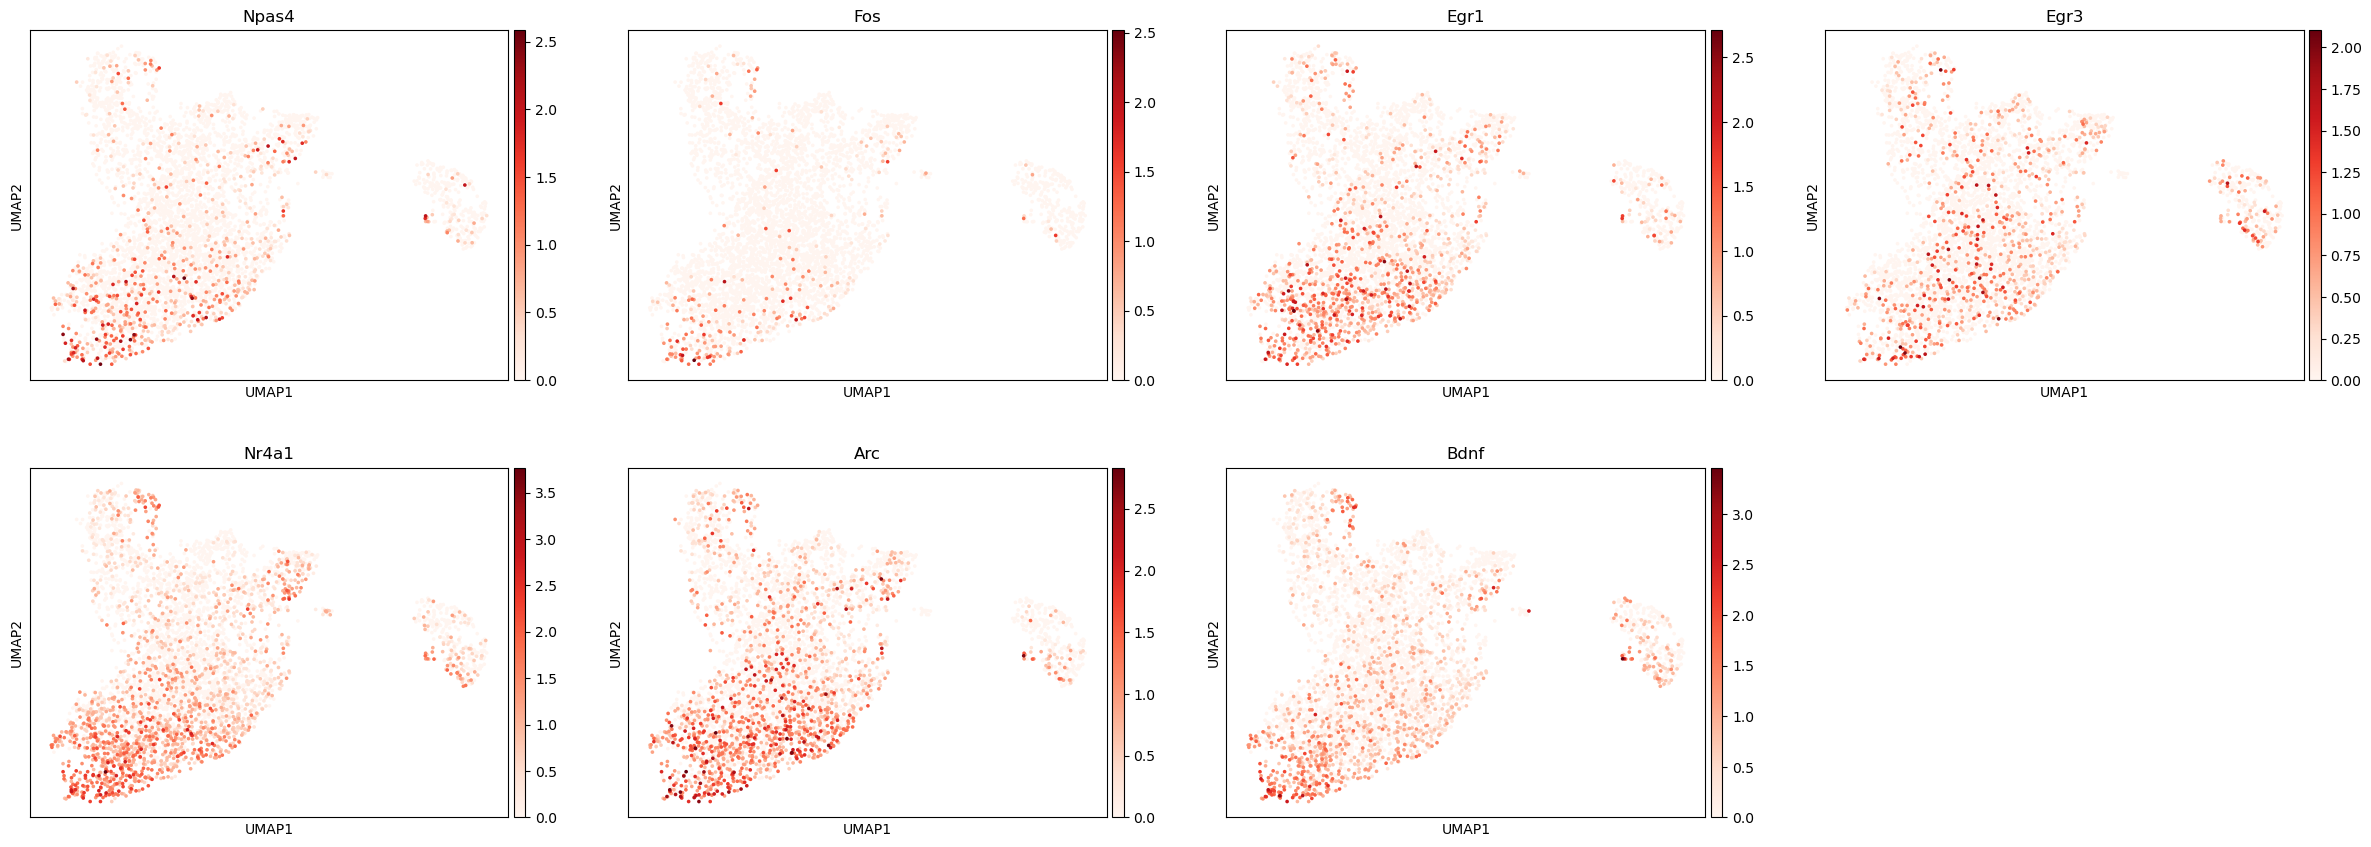

In [ ]:
sc.tl.louvain(adata, resolution=2)
sc.tl.umap(adata)
sc.pl.umap(adata, color=['louvain', 'condition'])
sc.pl.umap(adata, color=['Npas4', 'Fos', 'Egr1', 'Egr3', 'Nr4a1', 'Arc', 'Bdnf'], cmap='Reds')

In [ ]:
import pandas as pd

sc.tl.rank_genes_groups(adata, 'louvain')
top_markers = pd.DataFrame(adata.uns['rank_genes_groups']['names']).head(15)
top_markers.iloc[:,:12]

/Users/jack/miniconda3/envs/sc/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:396: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'names'] = self.var_names[global_indices]
/Users/jack/miniconda3/envs/sc/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:398: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'scores'] = scores[global_indices]
/Users/jack/miniconda3/envs/sc/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:401: PerformanceWarning:

,0,1,2,3,4,5,6,7,8,9,10,11
0,Cntnap2,Chrm3,Chrm3,Sox5,Ndst4,Negr1,4921539H07Rik,Tenm3,Chrm3,Thsd7b,Ntrk2,Ndst4
1,Chrm3,Nrxn3,4921539H07Rik,Kirrel3,Kcnip4,Dpyd,Chrm3,Ntm,Malat1,Ak5,Pde10a,Nr3c2
2,Marchf1,Epha6,Nrxn3,Cntn3,Nrxn3,Nkain3,Nrxn3,Egfem1,Epha6,Cpne7,1700016P03Rik,Kcnip4
3,Ntm,4921539H07Rik,Kcnab1,Grik4,Astn2,Ak5,Cadm2,Nrg1,Nrxn3,Ntm,Nr4a3,Nrxn3
4,Dcc,Lsamp,Cadm2,Ldb2,Pex5l,Mctp1,Kcnab1,Galntl6,Cadm2,Cacna1c,R3hdm1,Astn2
5,Kcnab1,Kcnab1,Ryr3,Cacna1c,Cracdl,Tenm1,Ryr3,Zbtb20,Tafa1,Opcml,Homer1,Fras1
6,Epha3,Egfem1,Zbtb20,Opcml,Epha6,Arhgef28,Epha6,Kcnab1,Galntl6,Kirrel3,Osbpl6,Kcnh7
7,Egfem1,Kcnh7,Syt7,Syt17,Cacna2d3,Celf4,Camk2b,Sema3e,4921539H07Rik,PTPRG,Nr4a1,Cacna2d3
8,Zbtb20,Cadm2,Kcnh7,Shisa9,Gm2164,Agbl4,Cntnap5c,Chrm3,Cntnap2,Cntnap2,Ptprn,Man1a
9,Cadm2,Ryr3,Nell1,Lrrtm4,Tbc1d1,Nrg1,Iqgap2,Tenm2,Snhg11,Itgbl1,Lncpint,4930578G10Rik
